In [1]:
CLUSTERING_ALGO = "kmeans"
FEAT_ENG_ALGO = "ssnn"

In [2]:
!pip install clustering-benchmarks -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.2/6.2 MB 32.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.5/6.5 MB 31.5 MB/s eta 0:00:00


In [3]:
import clustbench
data_url = "https://github.com/gagolews/clustering-data-v1/raw/v1.1.0"

In [4]:
battery_datasets_dict = {
                         'fcps': ['atom', 'chainlink', 'engytime', 'hepta', 'lsun', 'target', 'tetra', 'twodiamonds', 'wingnut'],
                         'uci': ['ecoli', 'glass', 'ionosphere', 'sonar', 'statlog', 'wdbc', 'wine', 'yeast'],
                         }

## Create autoencoder using pytorch

In [5]:
import numpy as np
from sklearn.neural_network import MLPRegressor
import pandas as pd

def ssnn_feat_eng(X, n_embeddings=2):

  # To store embeddings for each feature
  embeddings_list = []

  # Get the number of features
  n_samples, n_features = X.shape

  for feature_idx in range(n_features):

      # Prepare input by removing the current feature
      X_in = np.delete(X, feature_idx, axis=1)  # shape: (n_samples, n_features-1)

      # Target is the left-out feature
      y_target = X[:, feature_idx]  # shape: (n_samples,)

      # Define MLP
      mlp = MLPRegressor(
          hidden_layer_sizes=(64, n_embeddings),
          # Use 'identity' for linear activation in the hidden layers
          activation='logistic', #{'relu', 'logistic', 'identity', 'tanh'}
          max_iter=10000,
          random_state=42
      )

      # Fit the model
      mlp.fit(X_in, y_target)

      # Extract learned weights and biases
      coefs = mlp.coefs_
      intercepts = mlp.intercepts_

      # Forward pass to hidden layer 1 (linear)
      Z1 = X_in @ coefs[0] + intercepts[0]  # shape: (n_samples, 64)

      # Forward pass to hidden layer 2 (linear) → this is the embedding
      embeddings = Z1 @ coefs[1] + intercepts[1]  # shape: (n_samples, n_embeddings)

      # Append embeddings
      embeddings_list.append(embeddings)

  # Concatenate all embeddings horizontally
  X_new = np.hstack(embeddings_list)  # shape: (n_samples, n_embeddings * n_features)
  #X_new_df = pd.DataFrame(X_new, columns=[f'feature_{i+1}_emb_{j+1}' for i in range(n_features) for j in range(n_embeddings)])
  return X_new

# TabPFN

In [ ]:
# Install tabpfn from source
# Clone the repository: shallow for speedup
!git clone --depth 1 https://github.com/PriorLabs/tabpfn

# Speeding up installation in this notebook:
# Remove torch dependency as it is already installed on colab (do not run this in your local setup)
!sed -i "/torch/d" tabpfn/pyproject.toml

# Step 3: Install using the correct directory name 'tabpfn'
!uv pip install -e "tabpfn"

# Install TabPFN extensions for additional functionalities
!git clone https://github.com/PriorLabs/tabpfn-extensions

# Speeding up installation in this notebook:
# Remove torch dependency as it is already installed on colab (do not run this in your local setup)
!sed -i "/torch/d" tabpfn-extensions/pyproject.toml

!uv pip install -e tabpfn-extensions[all]

In [ ]:
# Simple import for TabPFN
from tabpfn import TabPFNClassifier

# Now you can use it like any other sklearn classifier
# model = TabPFNClassifier()
print("TabPFNClassifier imported successfully.")

In [ ]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

# Train and evaluate the TabPFN classifier
tabpfn_classifier = TabPFNClassifier(random_state=42)
tabpfn_classifier.fit(X_train, y_train)
y_pred_proba = tabpfn_classifier.predict_proba(X_test)

# Calculate the ROC AUC score
roc_auc = roc_auc_score(y_test, y_pred_proba[:, 1])
print(f"TabPFN ROC AUC Score: {roc_auc:.4f}")

## Function get_scores

Get the NCA score of a specific dataset using genie mst algorithm

In [6]:
import sklearn.cluster
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

def get_scores(battery, dataset, apply_scale=False):
  b = clustbench.load_dataset(battery, dataset, url=data_url)

  X_transformed = b.data
  if apply_scale:
    # Scale the data
    #scaler = StandardScaler()
    #X_transformed = scaler.fit_transform(X_transformed)
    X_transformed = clustbench.preprocess_data(X_transformed, random_state=42)

  m = sklearn.cluster.KMeans(n_clusters=b.n_clusters[0])
  results = clustbench.fit_predict_many(m, X_transformed, b.n_clusters[0])
  scores = clustbench.get_score(b.labels[0], results)

  return scores

## Function get_scores_with_autoencoder

Get the NCA score of a specific dataset applying the autoencoder transformation to the data and then using genie mst algorithm

In [7]:
import sklearn.cluster
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

def get_scores_with_feat_eng(battery, dataset, apply_scale=False, n_embeddings=2):
  b = clustbench.load_dataset(battery, dataset, url=data_url)

  X_transformed = ssnn_feat_eng(b.data, n_embeddings=n_embeddings)

  if apply_scale:
    # Scale the data
    #scaler = StandardScaler()
    #X_transformed = scaler.fit_transform(X_transformed)
    X_transformed = clustbench.preprocess_data(X_transformed, random_state=42)

  m = sklearn.cluster.KMeans(n_clusters=b.n_clusters[0])
  results = clustbench.fit_predict_many(m, X_transformed, b.n_clusters[0])
  scores = clustbench.get_score(b.labels[0], results)

  return scores

## Execute get_scores on all datasets as baseline

In [8]:
import tqdm
import pandas as pd
columns = ['Battery', 'Dataset', f'{CLUSTERING_ALGO} NCA Score']
df = pd.DataFrame(columns=columns)
scores_lists = {}
for col in columns:
  scores_lists[col] = []

for battery in tqdm.tqdm(battery_datasets_dict.keys(), desc="Processing Datasets"):
  for dataset in battery_datasets_dict[battery]:
    scores_lists['Battery'].append(battery)
    scores_lists['Dataset'].append(dataset)
    scores_lists[f'{CLUSTERING_ALGO} NCA Score'].append(get_scores(battery, dataset))

df_baseline = pd.DataFrame.from_dict(scores_lists)

Processing Datasets: 100%|██████████| 2/2 [00:33<00:00, 16.83s/it]


In [9]:
df_baseline.style.apply(lambda row:['']*len(row), axis=1)

,Battery,Dataset,kmeans NCA Score
0,fcps,atom,0.440000
1,fcps,chainlink,0.318000
2,fcps,engytime,0.903809
3,fcps,hepta,0.772222
4,fcps,lsun,0.705000
5,fcps,target,0.836364
6,fcps,tetra,1.000000
7,fcps,twodiamonds,1.000000
8,fcps,wingnut,0.927165
9,uci,ecoli,0.556758


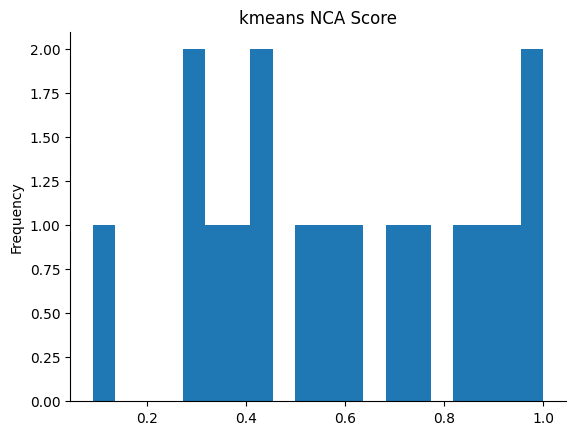

In [10]:
from matplotlib import pyplot as plt
df_baseline[f'{CLUSTERING_ALGO} NCA Score'].plot(kind='hist', bins=20, title=f'{CLUSTERING_ALGO} NCA Score')
plt.gca().spines[['top', 'right',]].set_visible(False)

## Execute get_scores_with_autoencoder on all datasets trying different numbers of embeddings (last hidden layer of the neural network)



In [11]:
n_embeddings_list = [2,4,8,16,32,64]

scores_lists = {}
for n_embs in tqdm.tqdm(n_embeddings_list, desc="Processing Datasets"):
  for battery in battery_datasets_dict.keys():
    for dataset in battery_datasets_dict[battery]:
      column_name = f'{CLUSTERING_ALGO}+{FEAT_ENG_ALGO} {n_embs} NCA Score'
      if column_name not in scores_lists:
        scores_lists[column_name] = []
      scores_lists[column_name].append(get_scores_with_feat_eng(battery, dataset, n_embeddings=n_embs))

df_ssnn = pd.DataFrame.from_dict(scores_lists)

Processing Datasets: 100%|██████████| 6/6 [17:33<00:00, 175.52s/it]


In [12]:
df = pd.concat([df_baseline, df_ssnn], axis=1)

# Final Results

In [14]:
for embs in n_embeddings_list:
  df[f'{CLUSTERING_ALGO}+{FEAT_ENG_ALGO} {embs} NCA Score (Difference)'] = df[f'{CLUSTERING_ALGO}+{FEAT_ENG_ALGO} {embs} NCA Score'] - df[f'{CLUSTERING_ALGO} NCA Score']

def highlight_scores(row):
    color = 'yellow'
    if row[f'{CLUSTERING_ALGO} NCA Score'] < 0.8 and \
     (row[f'{CLUSTERING_ALGO}+{FEAT_ENG_ALGO} 2 NCA Score'] > row[f'{CLUSTERING_ALGO} NCA Score'] or
      row[f'{CLUSTERING_ALGO}+{FEAT_ENG_ALGO} 4 NCA Score'] > row[f'{CLUSTERING_ALGO} NCA Score'] or
      row[f'{CLUSTERING_ALGO}+{FEAT_ENG_ALGO} 8 NCA Score'] > row[f'{CLUSTERING_ALGO} NCA Score'] or
      row[f'{CLUSTERING_ALGO}+{FEAT_ENG_ALGO} 16 NCA Score'] > row[f'{CLUSTERING_ALGO} NCA Score'] or
      row[f'{CLUSTERING_ALGO}+{FEAT_ENG_ALGO} 32 NCA Score'] > row[f'{CLUSTERING_ALGO} NCA Score'] or
      row[f'{CLUSTERING_ALGO}+{FEAT_ENG_ALGO} 64 NCA Score'] > row[f'{CLUSTERING_ALGO} NCA Score']):
        return [f'background-color: {color}'] * len(row)
    return [''] * len(row)

df.style.apply(highlight_scores, axis=1)

,Battery,Dataset,kmeans NCA Score,kmeans+ssnn 2 NCA Score,kmeans+ssnn 4 NCA Score,kmeans+ssnn 8 NCA Score,kmeans+ssnn 16 NCA Score,kmeans+ssnn 32 NCA Score,kmeans+ssnn 64 NCA Score,kmeans+ssnn 2 NCA Score (Difference),kmeans+ssnn 4 NCA Score (Difference),kmeans+ssnn 8 NCA Score (Difference),kmeans+ssnn 16 NCA Score (Difference),kmeans+ssnn 32 NCA Score (Difference),kmeans+ssnn 64 NCA Score (Difference)
0,fcps,atom,0.440000,0.407500,0.385000,0.410000,0.370000,0.382500,0.407500,-0.032500,-0.055000,-0.030000,-0.070000,-0.057500,-0.032500
1,fcps,chainlink,0.318000,0.426000,0.438000,0.248000,0.276000,0.304000,0.272000,0.108000,0.120000,-0.070000,-0.042000,-0.014000,-0.046000
2,fcps,engytime,0.903809,0.904785,0.550293,0.901855,0.698730,0.698730,0.699219,0.000977,-0.353516,-0.001953,-0.205078,-0.205078,-0.204590
3,fcps,hepta,0.772222,0.766667,1.000000,1.000000,1.000000,1.000000,1.000000,-0.005556,0.227778,0.227778,0.227778,0.227778,0.227778
4,fcps,lsun,0.705000,0.670000,0.690000,0.677500,0.432500,0.675000,0.550000,-0.035000,-0.015000,-0.027500,-0.272500,-0.030000,-0.155000
5,fcps,target,0.836364,0.837466,0.839118,0.704304,0.835813,0.840771,0.830303,0.001102,0.002755,-0.132060,-0.000551,0.004408,-0.006061
6,fcps,tetra,1.000000,0.513333,0.716667,0.973333,1.000000,1.000000,1.000000,-0.486667,-0.283333,-0.026667,0.000000,0.000000,0.000000
7,fcps,twodiamonds,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
8,fcps,wingnut,0.927165,0.905512,0.679134,0.811024,0.629921,0.661417,0.661417,-0.021654,-0.248031,-0.116142,-0.297244,-0.265748,-0.265748
9,uci,ecoli,0.556758,0.448430,0.320965,0.357985,0.336485,0.257136,0.282724,-0.108327,-0.235793,-0.198773,-0.220273,-0.299622,-0.274033
